In [1]:
import sqlite3
import pandas as pd

df = pd.read_csv('JC-202606-citibike-tripdata.csv')

conn = sqlite3.connect('citibike.db')
df.to_sql('trips', conn, if_exists='replace', index=False)

print("Loaded successfully. Row count:", pd.read_sql("SELECT COUNT(*) FROM trips", conn).iloc[0,0])

Loaded successfully. Row count: 109897


In [2]:
query = """
SELECT 
    CAST(strftime('%H', started_at) AS INTEGER) as hour_of_day,
    COUNT(*) as total_rides
FROM trips
GROUP BY hour_of_day
ORDER BY hour_of_day
"""
pd.read_sql(query, conn)

,hour_of_day,total_rides
0,0,1651
1,1,917
2,2,713
3,3,416
4,4,446
5,5,1170
6,6,3217
7,7,5582
8,8,7102
9,9,4594


In [3]:
query = """
SELECT 
    CASE WHEN strftime('%w', started_at) IN ('0','6') THEN 'Weekend' ELSE 'Weekday' END as day_type,
    CAST(strftime('%H', started_at) AS INTEGER) as hour_of_day,
    COUNT(*) as total_rides
FROM trips
GROUP BY day_type, hour_of_day
ORDER BY day_type, hour_of_day
"""
pd.read_sql(query, conn)

,day_type,hour_of_day,total_rides
0,Weekday,0,856
1,Weekday,1,333
2,Weekday,2,219
3,Weekday,3,126
4,Weekday,4,331
5,Weekday,5,1007
6,Weekday,6,2912
7,Weekday,7,5037
8,Weekday,8,6111
9,Weekday,9,3294


In [4]:
query = """
SELECT 
    CASE strftime('%w', started_at)
        WHEN '0' THEN 'Sunday' WHEN '1' THEN 'Monday' WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday' WHEN '4' THEN 'Thursday' WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday' END as day_of_week,
    CAST(strftime('%w', started_at) AS INTEGER) as day_num,
    CAST(strftime('%H', started_at) AS INTEGER) as hour_of_day,
    COUNT(*) as total_rides
FROM trips
GROUP BY day_of_week, day_num, hour_of_day
ORDER BY day_num, hour_of_day
"""
heatmap_df = pd.read_sql(query, conn)
heatmap_df.head(10)

,day_of_week,day_num,hour_of_day,total_rides
0,Sunday,0,0,403
1,Sunday,0,1,314
2,Sunday,0,2,300
3,Sunday,0,3,172
4,Sunday,0,4,69
5,Sunday,0,5,78
6,Sunday,0,6,116
7,Sunday,0,7,257
8,Sunday,0,8,399
9,Sunday,0,9,594


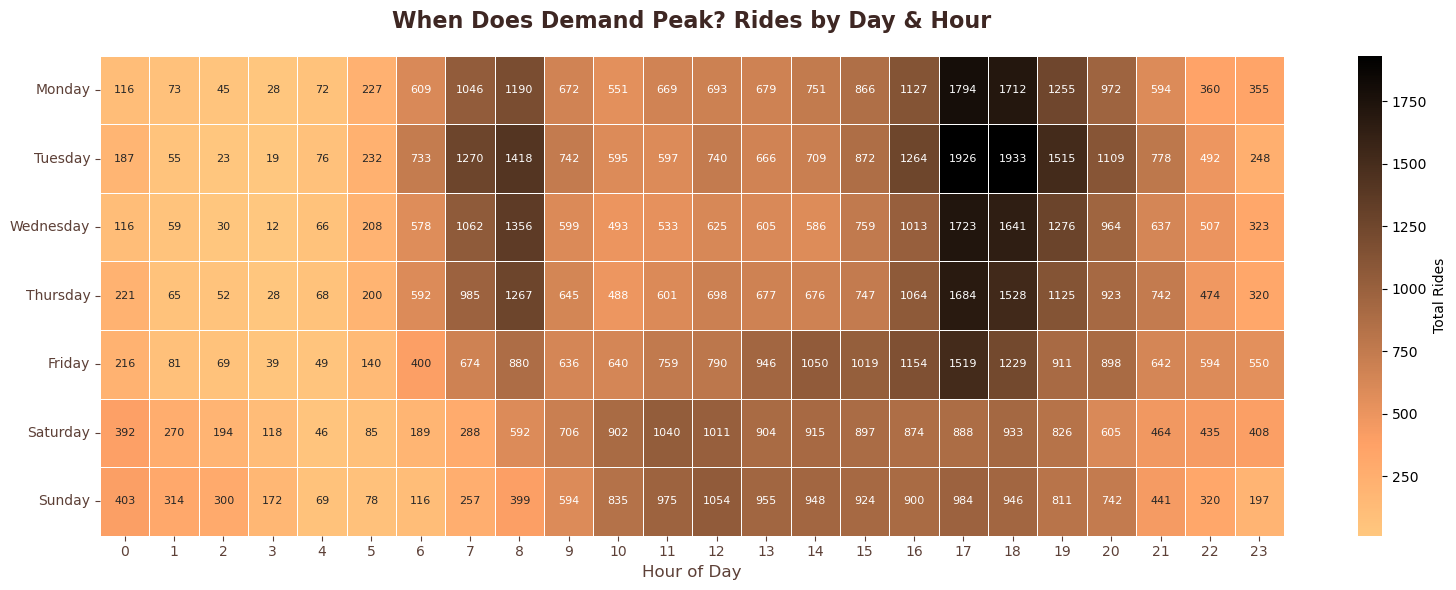

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot into a day x hour grid
heatmap_pivot = heatmap_df.pivot(index='day_of_week', columns='hour_of_day', values='total_rides')

# Reorder days Monday -> Sunday for a natural reading order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot.reindex(day_order)

# Modern brown-toned heatmap, consistent with your loan project's palette
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')

sns.heatmap(
    heatmap_pivot, 
    cmap='copper_r',  # reversed copper so darker = higher demand
    annot=True, fmt='d', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Total Rides'},
    ax=ax
)

ax.set_title('When Does Demand Peak? Rides by Day & Hour', 
             fontsize=16, fontweight='bold', color='#3E2723', pad=20)
ax.set_xlabel('Hour of Day', fontsize=12, color='#5D4037')
ax.set_ylabel('', fontsize=12)
ax.tick_params(colors='#5D4037')

plt.tight_layout()
plt.savefig('demand_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [6]:
query = """
SELECT 
    start_station_name,
    COUNT(*) as total_rides
FROM trips
GROUP BY start_station_name
ORDER BY total_rides DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,start_station_name,total_rides
0,Grove St PATH,5252
1,River St & Newark St,3704
2,Hoboken Terminal - Hudson St & Hudson Pl,2627
3,Bergen Ave & Sip Ave,2607
4,Hamilton Park,2319
5,11 St & Washington St,2270
6,12 St & Sinatra Dr N,2264
7,Exchange Pl,2251
8,14 St Ferry - 14 St & Shipyard Ln,2243
9,South Waterfront Walkway - Sinatra Dr & 1 St,2200


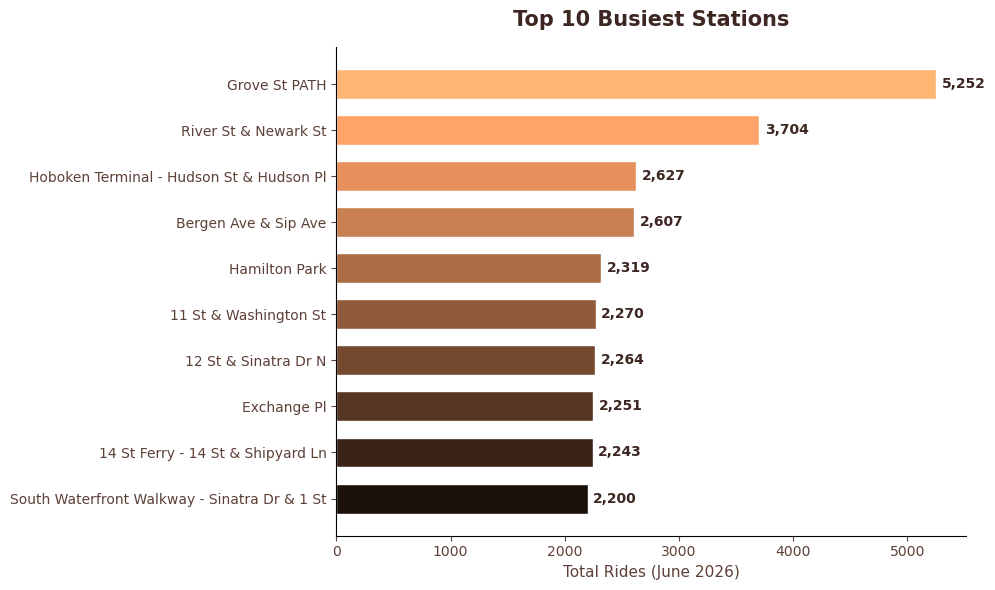

In [7]:
station_df = pd.read_sql(query, conn)  # reuse the query result from before, or rerun it

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

# Sort ascending so the biggest bar is at the top when plotted horizontally
station_df_sorted = station_df.sort_values('total_rides', ascending=True)

colors = sns.color_palette("copper", n_colors=len(station_df_sorted))

bars = ax.barh(station_df_sorted['start_station_name'], station_df_sorted['total_rides'], 
                color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, station_df_sorted['total_rides']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
            f'{val:,}', va='center', fontsize=10, fontweight='bold', color='#3E2723')

ax.set_title('Top 10 Busiest Stations', fontsize=15, fontweight='bold', color='#3E2723', pad=15)
ax.set_xlabel('Total Rides (June 2026)', fontsize=11, color='#5D4037')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#5D4037', labelsize=10)

plt.tight_layout()
plt.savefig('top_stations.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [8]:
query = """
SELECT 
    member_casual,
    CAST(strftime('%H', started_at) AS INTEGER) as hour_of_day,
    COUNT(*) as total_rides
FROM trips
GROUP BY member_casual, hour_of_day
ORDER BY member_casual, hour_of_day
"""
pd.read_sql(query, conn)

,member_casual,hour_of_day,total_rides
0,casual,0,756
1,casual,1,485
2,casual,2,427
3,casual,3,267
4,casual,4,165
5,casual,5,264
6,casual,6,585
7,casual,7,925
8,casual,8,1134
9,casual,9,960


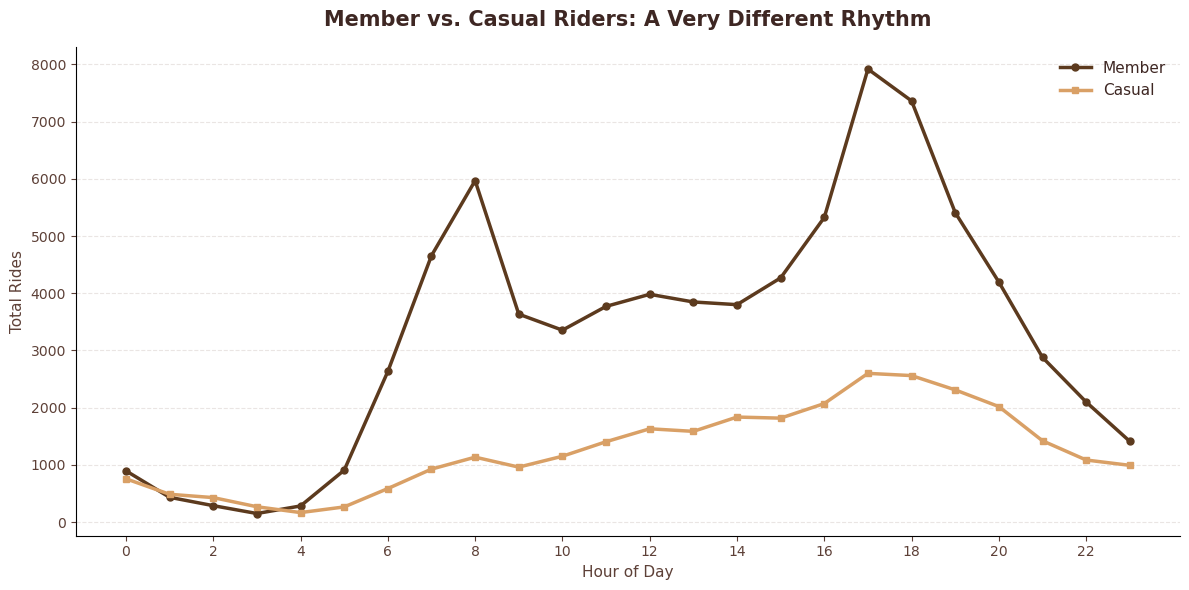

In [9]:
member_hour_df = pd.read_sql("""
SELECT 
    member_casual,
    CAST(strftime('%H', started_at) AS INTEGER) as hour_of_day,
    COUNT(*) as total_rides
FROM trips
GROUP BY member_casual, hour_of_day
ORDER BY member_casual, hour_of_day
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

for rider_type, color, marker in [('member', '#5C3A1E', 'o'), ('casual', '#D9A066', 's')]:
    subset = member_hour_df[member_hour_df['member_casual'] == rider_type]
    ax.plot(subset['hour_of_day'], subset['total_rides'], 
            label=rider_type.capitalize(), color=color, marker=marker, 
            linewidth=2.5, markersize=5)

ax.set_title('Member vs. Casual Riders: A Very Different Rhythm', 
             fontsize=15, fontweight='bold', color='#3E2723', pad=15)
ax.set_xlabel('Hour of Day', fontsize=11, color='#5D4037')
ax.set_ylabel('Total Rides', fontsize=11, color='#5D4037')
ax.legend(frameon=False, fontsize=11, labelcolor='#3E2723')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#5D4037')
ax.set_xticks(range(0, 24, 2))
ax.grid(axis='y', alpha=0.3, linestyle='--', color='#BCAAA4')

plt.tight_layout()
plt.savefig('member_vs_casual.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()